In [17]:
%matplotlib inline

import os

import pandas as pd

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
#plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import scipy.stats as st
from scipy.optimize import minimize

#### Shen, Hopkins luminosity function

40
40


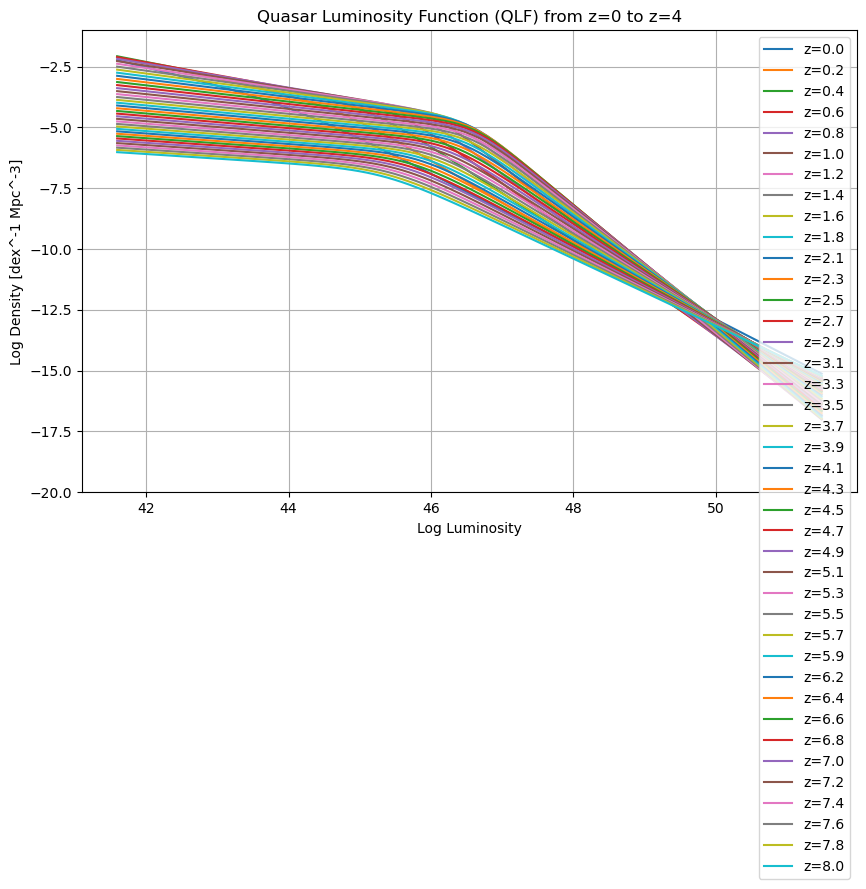

In [18]:
import sys
orig_dir = os.getcwd()
sys.path.append("/Users/colinburke/research/quasarlf/pubtools")
os.chdir("/Users/colinburke/research/quasarlf/pubtools")

from utilities import return_bolometric_qlf


# Assuming the function to get the quasar LF is named `get_quasar_lf` in the utilities.py file

# Generate redshift values from 0 to 4
z_bins = np.linspace(0, 8, 40)
print(len(z_bins))

# Compute QLF for each redshift
qlf_values = [return_bolometric_qlf(redshift=z, model='B') for z in z_bins]
print(len(qlf_values))

# Extract luminosity and density values
luminosities = qlf_values[0][0]  # Luminosities are the same for all redshifts
#M_grid = 90 - 2.5*luminosities # Mi(z=2)
M_grid = 91 - 2.5*luminosities # M2500 restframe

# Extract densities for each redshift
phi_log10 = np.array([qlf[1] for qlf in qlf_values])

# Plot the QLF
plt.figure(figsize=(10, 6))
for i, z in enumerate(z_bins):  # Plot every 10th redshift for clarity
    plt.plot(luminosities, phi_log10[i], label=f'z={z:.1f}')
    #plt.plot(apparent_magnitudes, densities[i * 10], label=f'z={z:.1f} (apparent)')
plt.xlabel('Log Luminosity')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Quasar Luminosity Function (QLF) from z=0 to z=4')
plt.ylim(-20, -1)
plt.legend()
plt.grid()
plt.show()

os.chdir(orig_dir)

### Ananna LF

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_21172/3403442321.py:131: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  phi_unobs_2d[i, :] = np.trapz(phi_3d[0], x=nH_unobs, axis=-1)


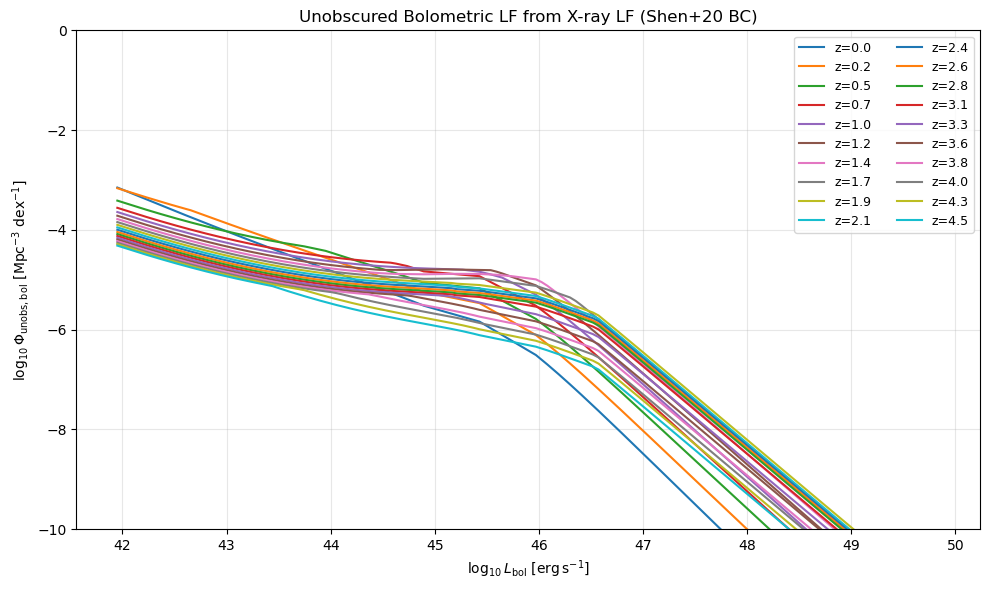

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq
import gzip

# ============================================================
# 1. Constants
# ============================================================
L_SUN_ERG_S = 3.828e33          # solar luminosity in erg/s
L0 = 1e10 * L_SUN_ERG_S         # 10^10 L_sun (erg/s)

# ============================================================
# 2. Shen+20 bolometric correction
#    L_bol / L_band = c1 (L_bol / 1e10 L_sun)^k1 + c2 (L_bol / 1e10 L_sun)^k2
# ============================================================
def bolometric_correction_shen20(L_bol,
                                 c1=4.073, k1=-0.026,
                                 c2=12.60, k2=0.278):
    """
    Shen+20 double power-law bolometric correction for a given L_bol (erg/s).

    Parameters
    ----------
    L_bol : float or array
        Bolometric luminosity in erg/s.

    Returns
    -------
    BC : float or array
        Bolometric correction, BC = L_bol / L_band.
    """
    x = L_bol / L0
    return c1 * x**k1 + c2 * x**k2


def Lbol_from_logLx_shen20(logLx_array,
                           c1=4.073, k1=-0.026,
                           c2=12.60, k2=0.278):
    """
    Convert log10 L_X (2-10 keV, erg/s) to log10 L_bol (erg/s)
    using the Shen+20 X-ray bolometric correction.

    Parameters
    ----------
    logLx_array : array-like
        log10 L_X (erg/s)

    Returns
    -------
    logLbol : ndarray
        log10 L_bol (erg/s)
    Lbol : ndarray
        L_bol (erg/s)
    """
    logLx_array = np.asarray(logLx_array)
    Lx_array = 10.0**logLx_array

    Lbol_array = np.empty_like(Lx_array)

    for i, Lx in enumerate(Lx_array):
        # Solve L_bol = BC(L_bol) * L_X
        def f(Lb):
            BC = bolometric_correction_shen20(Lb, c1=c1, k1=k1, c2=c2, k2=k2)
            return Lb - BC * Lx

        # Reasonable bracket: L_bol must be > L_X; upper bound not crazy huge
        L_min = Lx
        L_max = 1e4 * Lx

        Lbol_array[i] = brentq(f, L_min, L_max)

    logLbol = np.log10(Lbol_array)
    return logLbol, Lbol_array

# ============================================================
# 3. Build the XLF interpolator
# ============================================================
# Luminosity, redshift, and N_H grids
lumbins = np.linspace(41, 47, 150)   # log10 L_X (2-10 keV, erg/s)
zbin1  = np.arange(0.002, 0.1, 0.005)
zbin2  = np.arange(0.1,   1.0, 0.05)
zbin3  = np.arange(1.0,   5.05, 0.05)
zbins  = np.concatenate([zbin1, zbin2, zbin3])
nHbins = np.linspace(20, 26, 80)     # log10 N_H

# Read in matrix (shape: [something, nz, nL, nNH]; using [0] as LF)
with gzip.GzipFile("../../../ananna_xlf/final_sol_all.npy.gz", "r") as f:
    loading_matr = np.load(f)

# Interpolator: lum_func([z, logLx, logN_H]) -> φ(z, L_X, N_H)
# Here loading_matr[0] is assumed to be φ_X in *linear* units:
#   φ_X(z, logL_X, logN_H) = dN / (dV dlogL_X dlogN_H)
lum_func = RegularGridInterpolator(
    (zbins, lumbins, nHbins),
    loading_matr[0],
    method="linear",
    bounds_error=False,
    fill_value=0.0,
)

# ============================================================
# 4. Integrate over unobscured N_H (20 <= log N_H < 22)
# ============================================================
mask_unobs = (nHbins >= 20.0) & (nHbins < 22.0)
nH_unobs = nHbins[mask_unobs]

# Redshift and L_X grids for evaluation
z_bins_Ananna = np.linspace(0.01, 4.5, 20)   # plotting redshift grid
Lx_grid = lumbins                            # log10 L_X grid used by the XLF

phi_unobs_2d = np.zeros((len(z_bins_Ananna), len(Lx_grid)))  # φ_unobs(L_X, z)

for i, z in enumerate(z_bins_Ananna):
    # Grid over (z, logLx, logN_H) within unobscured N_H range
    ZZ, LL, NH = np.meshgrid(
        np.array([z]),
        Lx_grid,
        nH_unobs,
        indexing="ij"
    )  # shapes: (1, nL, nNH_unobs)

    pts = np.column_stack([ZZ.ravel(), LL.ravel(), NH.ravel()])

    # Evaluate LF
    phi_3d = lum_func(pts).reshape(1, len(Lx_grid), len(nH_unobs))

    # Integrate over log N_H to get unobscured LF φ_unobs(L_X, z)
    # Still in linear units, per dex in logL_X:
    #   φ_unobs_X(z, logL_X) = ∫ φ_X dlogN_H
    phi_unobs_2d[i, :] = np.trapz(phi_3d[0], x=nH_unobs, axis=-1)

# Clip and convert to log10 for convenience (this is still X-ray LF)
phi_unobs_clipped = np.clip(phi_unobs_2d, 1e-40, None)
phi_unobs_log10 = np.log10(phi_unobs_clipped)

# ============================================================
# 5. Convert L_X → L_bol (Shen+20) and apply Jacobian
# ============================================================
# Map each L_X grid point to L_bol
logLbol_grid, Lbol_grid = Lbol_from_logLx_shen20(Lx_grid)

# Compute Jacobian d logL_X / d logL_bol via finite differences
logLx = Lx_grid
logLbol = logLbol_grid

J = np.empty_like(logLx)  # J ≈ d logLx / d logLbol

# central differences for interior points
J[1:-1] = (logLx[2:] - logLx[:-2]) / (logLbol[2:] - logLbol[:-2])

# forward / backward differences at edges
J[0]    = (logLx[1]  - logLx[0])  / (logLbol[1]  - logLbol[0])
J[-1]   = (logLx[-1] - logLx[-2]) / (logLbol[-1] - logLbol[-2])

# Transform LF from per dex in logL_X to per dex in logL_bol:
#   φ_bol(z, logL_bol) = φ_X(z, logL_X(logL_bol)) * dlogL_X/dlogL_bol
phi_unobs_lin = 10.0**phi_unobs_log10           # back to linear
phi_bol_lin   = phi_unobs_lin * J[None, :]      # apply Jacobian along luminosity axis
phi_bol_clipped = np.clip(phi_bol_lin, 1e-40, None)
phi_bol_log10_Ananna = np.log10(phi_bol_clipped)

# ============================================================
# 6. Define magnitude grid based on L_bol
# ============================================================
# Use bolometric luminosities as "luminosities" array
luminosities = logLbol_grid            # log10 L_bol (erg/s)

# Magnitude grid, analogous to your QLF code
M_grid_Ananna = 91.0 - 2.5 * luminosities     # M_2500 rest-frame proxy

# NOTE:
# φ_bol_log10 is now per dex in logL_bol.
# If you later want φ per mag, you can multiply by dlogL_bol/dM = 0.4
# (which is just an overall normalization shift of log10(0.4) ≈ -0.398).

# ============================================================
# 7. Plot unobscured *bolometric* LF vs log L_bol
# ============================================================
plt.figure(figsize=(10, 6))

for i, z in enumerate(z_bins_Ananna):
    plt.plot(luminosities, phi_bol_log10_Ananna[i, :], label=f"z={z:.1f}")

plt.xlabel(r'$\log_{10} L_{\mathrm{bol}}\ \mathrm{[erg\,s^{-1}]}$')
plt.ylabel(r'$\log_{10} \Phi_{\rm unobs,bol}\ \mathrm{[Mpc^{-3}\ dex^{-1}]}$')
plt.title('Unobscured Bolometric LF from X-ray LF (Shen+20 BC)')
plt.ylim(-10, 0)   # adjust as needed
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# At this point you have:
#   - logLbol_grid (luminosities) : log10 L_bol (erg/s)
#   - M_grid_Ananna               : magnitude proxy from L_bol
#   - phi_bol_log10               : log10 LF per dex in logL_bol


### Mock data

In [20]:
import numpy as np
import astropy.units as u
from scipy.interpolate import RegularGridInterpolator

def mock_m_per_zbin(
    phi_log10,         # 2D array: either (len(z_bins)-1, len(M_grid)) at z-mids OR (len(z_bins), len(M_grid)) at edges
    M_grid,            # 1D array of absolute magnitudes (any order; will be sorted ascending)
    z_bins,            # 1D array of redshift bin edges
    area_deg2,         # survey area in deg^2
    alpha_nu,          # AB spectral index: f_nu ∝ nu^{alpha_nu}
    dalpha_nu,         # scatter
    cosmo,             # astropy cosmology
    *,
    z_res=512,         # z sampling resolution for integrals/CDFs inside each bin
    m_scatter=0.0,     # optional Gaussian mag scatter
    kcorr_zref=2.0,   # if QLF is in Mi(zref), set e.g. kcorr_zref=2.0; otherwise None for same-filter K
    completeness=None, # optional callable C(m, z) -> [0,1] acceptance prob
    m_lim=None,        # optional magnitude limit (keep m < m_lim)
    rng=None,
    # ---- new options (backward compatible) ----
    return_z=False,        # also return per-bin redshift samples and realized counts
    return_global=False,   # also return concatenated (z_all, m_all, bin_index)
    verbose=False,
 ):
    """
    Returns (by default, to preserve your original signature)
    --------------------------------
    per_z_m : list[np.ndarray]
        List of length len(z_bins)-1; each entry is the array of sampled apparent magnitudes
        (after scatter/selection) in that z-bin.
    Nexp_per_bin : np.ndarray
        Expected counts per redshift bin (before completeness / m_lim).

    If return_z is True, two more items are appended:
      per_z   : list[np.ndarray]  (sampled redshifts kept after selection, per bin)
      Nsel_per_bin : np.ndarray   (realized counts after selection per bin)

    If return_global is True as well, three more items are appended:
      z_all, m_all, bin_index : concatenated arrays of all selected objects and their bin indices.
    """
    rng = np.random.default_rng() if rng is None else rng

    # ---- prep grids & φ
    M = np.asarray(M_grid)
    order = np.argsort(M)         # ensure ascending M
    M = M[order]
    nM = len(M)

    z_bins = np.asarray(z_bins)
    z_mids = 0.5*(z_bins[:-1] + z_bins[1:])

    phi = np.asarray(phi_log10)
    # Orient φ so axis0 = z, axis1 = M
    if   phi.shape == (len(z_mids), len(M_grid)):
        z_support = z_mids
    elif phi.shape == (len(z_bins), len(M_grid)):
        z_support = z_bins
    elif phi.shape == (len(M_grid), len(z_mids)):
        phi = phi.T; z_support = z_mids
    elif phi.shape == (len(M_grid), len(z_bins)):
        phi = phi.T; z_support = z_bins
    else:
        raise ValueError("phi_log10 must be shaped either (len(z_bins)-1, len(M_grid)) or (len(z_bins), len(M_grid)), "
                         "optionally transposed.")

    # Reorder φ columns to match sorted M
    phi = phi[:, order]

    # Interpolator in (z, M) over log10 φ
    rgi = RegularGridInterpolator(
        (z_support, M), phi,
        method="linear", bounds_error=False, fill_value=-np.inf
    )

    # robust ΔM from edges
    edges = np.empty(nM+1)
    edges[1:-1] = 0.5*(M[1:] + M[:-1])
    edges[0]    = M[0]  - 0.5*(M[1]-M[0])
    edges[-1]   = M[-1] + 0.5*(M[-1]-M[-2])
    dM = np.diff(edges)

    area_sr = area_deg2 * (np.pi/180.0)**2
    per_z_m = []
    per_z_m_rest = []
    Nexp_per_bin = np.zeros(len(z_bins)-1)
    # new
    per_z = []
    Nsel_per_bin = np.zeros(len(z_bins)-1, dtype=int)

    for i, (z1, z2) in enumerate(zip(z_bins[:-1], z_bins[1:])):
        # fine z-grid for this bin
        z = np.linspace(z1, z2, z_res)
        dVdz = cosmo.differential_comoving_volume(z).to_value(u.Mpc**3/u.sr) * area_sr

        DM = 5.0*np.log10(cosmo.luminosity_distance(z).to_value(u.pc)) - 5.0

        # φ_int(z) = ∫ φ(M,z) dM
        ZZ = np.repeat(z, nM)
        MM = np.tile(M, z.size)
        logphi_flat = rgi(np.column_stack([ZZ, MM]))
        phi_flat = np.where(np.isfinite(logphi_flat), 10.0**logphi_flat, 0.0)
        phi_zM = phi_flat.reshape(z.size, nM)
        phi_int_z = np.sum(phi_zM * dM[None, :], axis=1)

        # Expected count in this z-bin (pre-selection):
        Nexp = np.trapz(phi_int_z * dVdz, z)
        Nexp_per_bin[i] = Nexp

        # Draw total N and sample z with weight ∝ φ_int(z) dV/dz
        N = rng.poisson(Nexp)
        if N == 0 or not np.isfinite(Nexp) or Nexp <= 0:
            per_z_m.append(np.empty(0, float))
            per_z.append(np.empty(0, float))
            if verbose:
                print(f"[bin {i+1}/{len(z_bins)-1}] z=({z1:.3f},{z2:.3f}) Nexp={Nexp:.2f} -> N=0")
            continue

        wz = phi_int_z * dVdz
        cdf_z = np.cumsum(wz)
        if cdf_z[-1] <= 0 or not np.isfinite(cdf_z[-1]):
            per_z_m.append(np.empty(0, float))
            per_z.append(np.empty(0, float))
            if verbose:
                print(f"[bin {i+1}/{len(z_bins)-1}] empty weight over z; skipping.")
            continue
        cdf_z /= cdf_z[-1]
        z_samp = np.interp(rng.random(N), cdf_z, z)

        # For all sampled z, sample M | z by inverse-CDF of φ(M,z)
        ZZs = np.repeat(z_samp, nM)
        MM  = np.tile(M, z_samp.size)
        logphi_flat = rgi(np.column_stack([ZZs, MM]))
        phi_flat = np.where(np.isfinite(logphi_flat), 10.0**logphi_flat, 0.0)
        phi_M_given_z = phi_flat.reshape(z_samp.size, nM)

        # Build per-object CDFs over M
        wM = phi_M_given_z * dM[None, :]
        rowsum = wM.sum(axis=1)
        valid = rowsum > 0
        if not np.all(valid):
            z_samp = z_samp[valid]
            wM = wM[valid]
            rowsum = rowsum[valid]
            if z_samp.size == 0:
                per_z_m.append(np.empty(0, float))
                per_z.append(np.empty(0, float))
                if verbose:
                    print(f"[bin {i+1}/{len(z_bins)-1}] no valid M|z draws; skipping.")
                continue

        cdfM = np.cumsum(wM, axis=1) / rowsum[:, None]
        _u = rng.random(z_samp.size)

        # find index where CDF crosses u
        idx = (cdfM < _u[:, None]).sum(axis=1)
        idx = np.clip(idx, 1, nM-1)
        cdf_lo = cdfM[np.arange(z_samp.size), idx-1]
        cdf_hi = cdfM[np.arange(z_samp.size), idx]
        M_lo   = M[idx-1]
        M_hi   = M[idx]
        # linear interpolation within the bin
        t = (_u - cdf_lo) / (cdf_hi - cdf_lo + 1e-12)
        M_samp = M_lo + t*(M_hi - M_lo)

        # Distance modulus at the sampled redshifts
        DM_s = 5.0 * np.log10(cosmo.luminosity_distance(z_samp).to_value(u.pc)) - 5.0

        # Draw per-object spectral slopes using the local RNG (for reproducibility)
        alpha_nu_samp = alpha_nu + rng.normal(0.0, dalpha_nu, size=z_samp.shape)

        # Shen et al. (2009) intrinsic scatter in absolute magnitude, once per object
        delta_M_shen = 0.0 #rng.normal(0.0, 0.166, size=M_samp.size)
        M_intrinsic  = M_samp + delta_M_shen   # intrinsic Mi(z=2) per object

        # --- Observed-frame magnitude in the survey band (using Mi(zref)) ---

        if kcorr_zref is None:
            # If this branch is ever used, treat M_intrinsic as a true rest-frame M in the survey band
            K_s = -2.5 * (1.0 + alpha_nu_samp) * np.log10(1.0 + z_samp)
        else:
            # Standard Mi(zref) convention: QLF is in Mi(zref), e.g. zref=2
            # m_obs = Mi(zref) + DM(z) + K(z; zref)
            K_s = -2.5 * (1.0 + alpha_nu_samp) * np.log10((1.0 + z_samp) / (1.0 + kcorr_zref))

        m_samp = M_intrinsic + DM_s + K_s   # apparent magnitude in the survey band

        # --- Apparent magnitude at rest-frame 2500 Å (m_2500) ---

        # Mi(z=2) is basically a rest-frame magnitude at λ_i_rest = λ_i / (1+zref).
        # If you want the exact 2500 Å value, apply a small color term using alpha_nu_samp.

        lam_i_obs  = 7480.0    # SDSS i-band effective wavelength [Å], adjust if needed
        lam_2500   = 2500.0    # target rest wavelength [Å]
        lam_i_rest = lam_i_obs / (1.0 + kcorr_zref)   # ≈ 2500 Å for zref=2

        # Convert Mi(z=2) -> M_2500 using f_nu ∝ nu^{alpha_nu}:
        # M_2500 - M_i_rest = -2.5 * alpha_nu * log10(lam_i_rest / 2500)
        color_term = -2.5 * alpha_nu_samp * np.log10(lam_i_rest / lam_2500)

        M_2500 = M_intrinsic + color_term
        m_rest_samp = M_2500 + DM_s   # this is m_2500(z)

        # Optional extra photometric scatter (independent of Shen intrinsic scatter)
        if m_scatter > 0:
            m_samp      = m_samp      + rng.normal(0.0, m_scatter, size=m_samp.size)
            m_rest_samp = m_rest_samp + rng.normal(0.0, m_scatter, size=m_rest_samp.size)

        if m_lim is not None and m_samp.size > 0:
            keep = m_samp < m_lim
            m_samp = m_samp[keep]
            m_rest_samp = m_rest_samp[keep]
            z_samp = z_samp[keep]

        if completeness is not None and m_samp.size > 0:
            p = np.clip(completeness(m_samp, z_samp), 0.0, 1.0)
            keep = rng.random(m_samp.size) < p
            m_samp = m_samp[keep]
            m_rest_samp = m_rest_samp[keep]
            z_samp = z_samp[keep]

        per_z_m.append(m_samp)
        per_z_m_rest.append(m_rest_samp)
        per_z.append(z_samp)
        Nsel_per_bin[i] = m_samp.size

        if verbose:
            print(f"[bin {i+1}/{len(z_bins)-1}] z=({z1:.3f},{z2:.3f}) "
                  f"Nexp={Nexp:.1f} -> drew {N}, kept {m_samp.size}")

    # ---- returns (backward compatible by default) ----
    if not (return_z or return_global):
        return per_z_m, Nexp_per_bin

    # otherwise, append extras
    out = (per_z_m, Nexp_per_bin, per_z, Nsel_per_bin)
    if return_global:
        if any(len(v) for v in per_z_m):
            z_all = np.concatenate([z for z in per_z if z.size])
            m_all = np.concatenate([m for m in per_z_m if m.size])
            m_rest_all = np.concatenate([m for m in per_z_m_rest if m.size])
            bin_index = np.concatenate([
                np.full(len(m), i, dtype=int) for i, m in enumerate(per_z_m) if len(m)
            ])
        else:
            z_all = np.empty(0, float); m_all = np.empty(0, float); bin_index = np.empty(0, int)
        out = out + (z_all, m_all, m_rest_all, bin_index)
    return out


### Hopkins

In [21]:
area_deg2 = 5.0
alpha_nu = -0.5  # spectral index
dalpha_nu = 0.3 # scatter
per_z_m, Nexp, per_z, Nsel, z_all, m_all, m_rest_all, bin_idx = mock_m_per_zbin(phi_log10, M_grid, z_bins, area_deg2, alpha_nu, dalpha_nu, cosmo, kcorr_zref=2.0, return_z=True, return_global=True)

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_21172/1572451249.py:95: RuntimeWarning: divide by zero encountered in log10
  DM = 5.0*np.log10(cosmo.luminosity_distance(z).to_value(u.pc)) - 5.0
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_21172/1572451249.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Nexp = np.trapz(phi_int_z * dVdz, z)


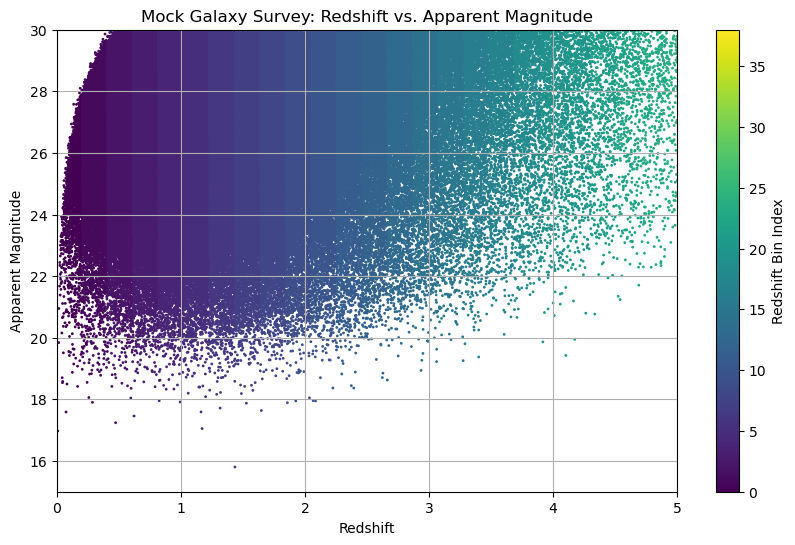

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(z_all, m_all, c=bin_idx, cmap='viridis', s=1)
plt.colorbar(label='Redshift Bin Index')
plt.xlabel('Redshift')
plt.ylabel('Apparent Magnitude')
plt.title('Mock Galaxy Survey: Redshift vs. Apparent Magnitude')
plt.xlim(0, 5)
plt.ylim(15, 30)
plt.grid()
plt.show()

In [23]:
import h5py

mask = m_all < 28.0
with h5py.File('/Users/colinburke/research/isaque/eztaox/qvc/data/mock_mag_z.h5', 'w') as h5file:
    h5file.create_dataset('z', data=z_all[mask])
    h5file.create_dataset('apparent_mag_i', data=m_all[mask])
    h5file.create_dataset('apparent_mag_i_rest', data=m_rest_all[mask])

### Ananna

In [28]:
area_deg2 = 50.0
alpha_nu = -0.5  # spectral index
dalpha_nu = 0.3 # scatter
per_z_m, Nexp, per_z, Nsel, z_all, m_all, m_rest_all, bin_idx = mock_m_per_zbin(phi_bol_log10_Ananna, M_grid_Ananna, z_bins_Ananna, area_deg2, alpha_nu, dalpha_nu, cosmo, kcorr_zref=2.0, return_z=True, return_global=True)

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_21172/1572451249.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Nexp = np.trapz(phi_int_z * dVdz, z)


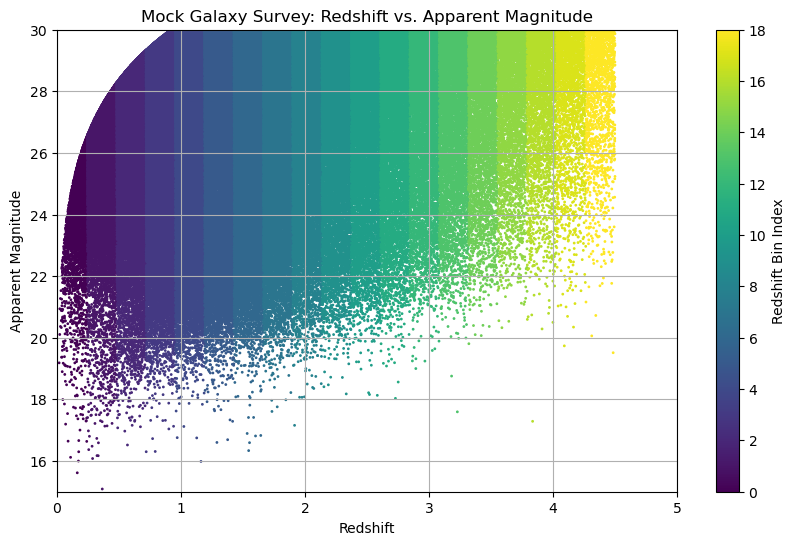

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(z_all, m_rest_all, c=bin_idx, cmap='viridis', s=1)
plt.colorbar(label='Redshift Bin Index')
plt.xlabel('Redshift')
plt.ylabel('Apparent Magnitude')
plt.title('Mock Galaxy Survey: Redshift vs. Apparent Magnitude')
plt.xlim(0, 5)
plt.ylim(15, 30)
plt.grid()
plt.show()

In [30]:
import h5py

mask = m_all < 28.0
with h5py.File('/Users/colinburke/research/isaque/eztaox/qvc/data/mock_mag_z_ananna.h5', 'w') as h5file:
    h5file.create_dataset('z', data=z_all[mask])
    h5file.create_dataset('apparent_mag_i', data=m_all[mask])
    h5file.create_dataset('apparent_mag_i_rest', data=m_rest_all[mask])

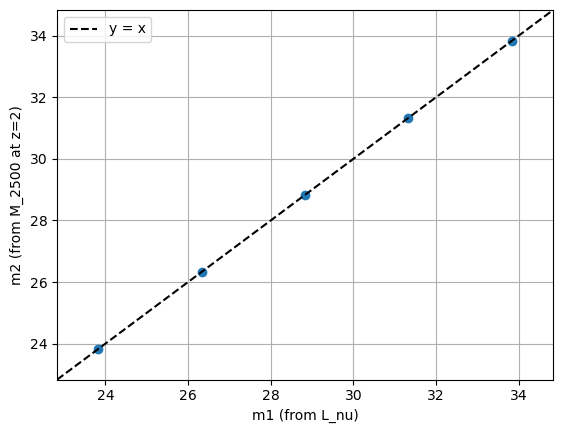

In [27]:
def compute_apparent_mag_2500_astropy(logL2500, z):
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    c = 2.99792458e10  # cm/s
    lambda_ = 2500e-8  # cm

    DL = cosmo.luminosity_distance(z).to(u.cm).value  # cm

    log_Lnu = logL2500 + np.log10(lambda_ / c)
    log_fnu = log_Lnu - np.log10(4 * np.pi * DL**2)
    m_ab = -2.5 * log_fnu - 48.60

    return m_ab

z_test = 4.1

logLbols = np.array([42.0, 43.0, 44.0, 45.0, 46.0])

m1 = compute_apparent_mag_2500_astropy(logLbols - np.log10(4.8), z_test)
M_2500 = 90 - 2.5*logLbols
m2 = M_2500 + 5.0 * np.log10(cosmo.luminosity_distance(z_test).to_value(u.pc)) - 5.0

M_2500 = 91.0 - 2.5 * logLbols # Note correct formula for M_2500
DM = 5.0 * np.log10(cosmo.luminosity_distance(z_test).to_value(u.pc)) - 5.0
m2 = M_2500 + DM

plt.plot(m1, m2, 'o')

lims = [min(np.min(m1), np.min(m2)) - 1, max(np.max(m1), np.max(m2)) + 1]
plt.plot(lims, lims, 'k--', label='y = x')
plt.xlabel('m1 (from L_nu)')
plt.ylabel('m2 (from M_2500 at z=2)')
plt.legend()
plt.grid()
plt.xlim(lims)
plt.ylim(lims)
plt.show()